In [1]:

import numpy as np
from scipy import signal
from matplotlib import pyplot as plt
from matplotlib import patches 
from numpy import fft

import schemdraw
from schemdraw import flow
import schemdraw as schem
import schemdraw.elements as e
from schemdraw import dsp

%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")


Digital filters are delay-based processing units. In short: they affect a signal by overlapping it with delayed versions of the input - and output. The main application of filters in DSP is the shaping of the spectrum of signals. This can affect the magnitude spectrum by boosting or suppressing certain frequencies, or the phase spectrum by delaying specific frequencies. Equalizers, reverbs, oscillators and more can be realized with digital filters.

There are two basic categories of digital filters in signal processing:

- **FIR Filters**
- **IIR Filters**

------

# FIR Filters

Finite Impulse Response (FIR) filters can be considered simple convolution processors. They are implemented without recursion, respectively feedback. And they have a finite impulse response.

**FIR filters are allways stable**  and easy to design, yet they are more CPU expensive and can cause more delay.
**FIR filters can have linear phase.** This property is desirable in many dsp applications.


## Impulse Response

The impulse response (IR) of an FIR filter is only the filter coefficients. The following plot shows the IR for a 10th order FIR lowpass filter. All samples after sample 10 are 0 in this $h[n]$:

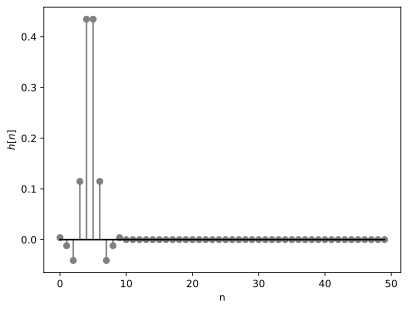

In [2]:
fs = 16000 
fc = 100
N  = 100

numtaps = 10
f       = 0.5

s = signal.firwin(numtaps, f)

s = np.append(s,np.zeros(40))
plt.stem(s, 'gray', markerfmt='gray', basefmt='k')

plt.xlabel('n')
plt.ylabel('$h[n]$');

## Frequency Response

The frequency response of the FIR filter is the Fourier transform of its impulse response $h[n]$:

$$
H(f) = \mathcal{F}\{ h[n] \}
$$

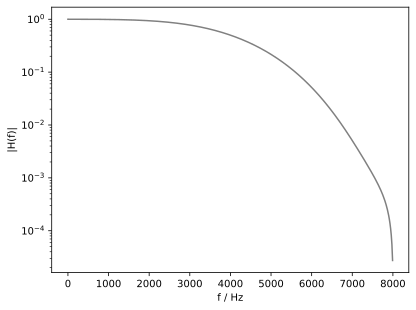

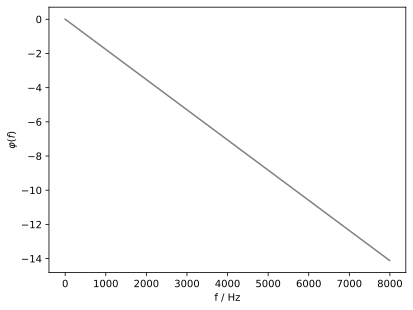

In [3]:

h  = np.append(s,np.zeros(950))

N = len(h)

H  = fft.fft(h);
f  = np.linspace(0,fs,N)

plt.semilogy(f[0:int(N/2)],abs(H[0:int(N/2)]),'gray');
plt.xlabel('f / Hz')
plt.ylabel('|H(f)|')
plt.show()


plt.plot(f[0:int(N/2)],np.unwrap(np.angle(H[0:int(N/2)])),'gray');
plt.xlabel('f / Hz')
plt.ylabel('$\\varphi(f)$');

-----

# IIR Filters

Infinite Impulse Response (IIR) filters are recursive computational structures. They have an infinite impulse response, that either converges to zero or - if unstable - to infinity.
IIR filters are used for many time-critical operations, since they are less CPU hungry and create less delay. 

In contrast to FIR filters, **IIR filters can be unstable** and alter the phase of signals in sometimes undesirable ways.
Impulse Response

The following plot shows the IR for a 3rd order Butterworth lowpass filter. The recursion results in a convergence towards 0.

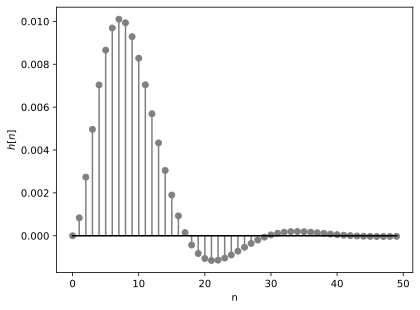

In [4]:
fs = 16000 
fc = 400
N  = 50

t  = np.linspace(0,10,1)

b, a = signal.iirfilter(3, fc/fs, btype='lowpass', analog=True, ftype='butter')

t,h = signal.impulse([b,a],N=N)

plt.stem(h, 'gray', markerfmt='gray', basefmt='k')

plt.xlabel('n')
plt.ylabel('$h[n]$');

## Frequency Response

As for the FIR filter, the frequency response of the IIR filter is the  DFT of the impulse response $h[n]$: 

$$
H(f) = \mathcal{F}\{ h[n] \}
$$

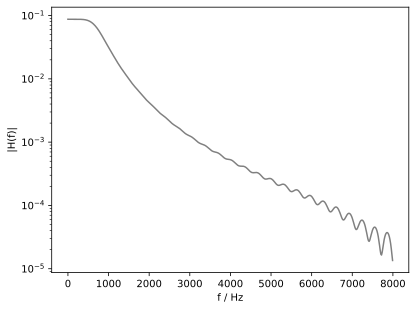

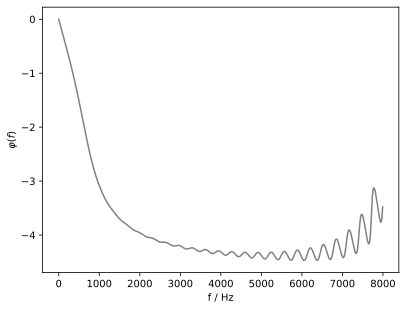

In [5]:

h  = np.append(h,np.zeros(950))

N = len(h)

H  = fft.fft(h);
f  = np.linspace(0,fs,N)

plt.semilogy(f[0:int(N/2)],abs(H[0:int(N/2)]),'gray');
plt.xlabel('f / Hz')
plt.ylabel('|H(f)|')
plt.show()


plt.plot(f[0:int(N/2)],np.unwrap(np.angle(H[0:int(N/2)])),'gray');
plt.xlabel('f / Hz')
plt.ylabel('$\\varphi(f)$');